In [1]:
import torch
import json
from ptlpinns.models import model, transfer
from ptlpinns.perturbation import LPM, standard
from ptlpinns.odes import forcing, numerical, equations
import numpy as np
import math
import matplotlib.pyplot as plt

/home/jovyan/PTL-PINNs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load model

In [2]:
name = "undamped_k12"

undamped_path = f"/home/jovyan/PTL-PINNs/ptlpinns/models/train/{name}"
undamped_name = f"model_{name}.pth"
undamped_model, training_log = model.load_model(undamped_path, undamped_name)

12 True True True 1.0 16 [256, 256, 512]


### Problem definition

In [ ]:
t_span = (0, 10)
N = 500
t_eval = np.linspace(t_span[0], t_span[1], N)

# Fixed problem parameters
w_0  = 1
zeta = 0.0
ic   = [1, 0]      # x(0)=1, x'(0)=0
q    = [(3, 1)]    # cubic nonlinearity
p_max = 5

# High-accuracy reference: (N-1)*REFINE+1 = 149 001 ≈ 150 000 output points.
# Comparison: every REFINE-th reference point → 150 aligned points per side.
REFINE = 1

# Epsilon sweep
epsilon_values = np.arange(0.01, 2.0, 0.05)

forcing_fn = forcing.zeroes_2D(numpy=True)  # zero forcing (free oscillation)

### Compute latent representations

In [4]:
H_dict = transfer.compute_H_dict(undamped_model, N=N, bias=True, t_span=t_span)

## Epsilon sweep — fixed IC `[x(0), x'(0)] = [1, 0]`

The undamped Duffing oscillator is
$$\ddot{x} + x + \varepsilon x^3 = 0, \quad x(0)=1,\; \dot{x}(0)=0.$$
For each $\varepsilon$ we run the PTL-PINN **Lindstedt–Poincaré** pipeline up
to order $p_{\max} = 5$ and measure the MAE against a high-accuracy numerical
reference at every perturbation order.

**Reference accuracy:** the ODE is integrated with `(N-1)*REFINE+1 ≈ 150 000`
output points (scipy RK45, `rtol=atol=1e-10`).  The error is computed on the
same 150-point PTL-PINN grid by taking every `REFINE`-th reference point.

In [5]:
results = {}

for epsilon in epsilon_values:

    ode = equations.ode_oscillator_1D(
        w_0=w_0, zeta=zeta,
        forcing_1D=lambda t: np.zeros_like(t),
        q=q, epsilon=epsilon,
    )

    if epsilon == 0.0:
        x_exact = np.cos(t_eval)
        results[epsilon] = {
            "mode": "linear",
            "error": [0.0] * (p_max + 1),
            "t_eval_lpm": t_eval,
            "x_num": x_exact,
            "x_pinn": x_exact,
        }
        continue

    # Per-order MAE with ~150 000-point reference (stride REFINE=1000)
    error, w_sol = LPM.compute_error_per_order_lpm(
        H_dict=H_dict,
        training_log=training_log,
        w_0=w_0,
        zeta=zeta,
        epsilon=epsilon,
        p_max=p_max,
        ic=ic,
        forcing_function=forcing_fn,
        q=q,
        ode=ode,
        t_eval=t_eval,
        t_span=t_span,
        N=N,
        refine=REFINE,
        rwtol=0.0,
        check_divergence=False,
    )

    # Corrected frequency and rescaled time grid
    w_series = LPM.calculate_w_series(w_sol[0], epsilon, rwtol=0.0, check_divergence=False)
    w_final  = w_series[-1]
    t_eval_lpm, _ = LPM.t_eval_lpm(t_eval, w_final)

    # PTL-PINN trajectory at p_max
    w_sol_traj = []
    NN_TL, _, _ = transfer.compute_perturbation_solution(
        w_0_list=[w_0], zeta_list=[zeta], beta_list=[epsilon],
        p_list=[p_max], ic_list=[ic], forcing_list=[forcing_fn],
        H_dict=H_dict, t_eval=t_eval, training_log=training_log,
        all_p=True, comp_time=False, solver="LPM",
        w_sol=w_sol_traj, power=q,
    )
    NN_TL = NN_TL.squeeze()  # type: ignore

    # High-accuracy reference on the LPM time grid
    t_lpm_hi = np.linspace(t_eval_lpm[0], t_eval_lpm[-1], (N - 1) * REFINE + 1)
    x_num = numerical.solve_ode_equation(
        ode, (t_lpm_hi[0], t_lpm_hi[-1]), t_lpm_hi, ic
    )[0, :][::REFINE]   # subsample to N points

    results[epsilon] = {
        "mode": "lpm",
        "error": error,
        "w_sol": w_sol,
        "w_final": w_final,
        "t_eval_lpm": t_eval_lpm,
        "x_num": x_num,
        "x_pinn": NN_TL[:, 0],
    }

In [6]:
sweep_eps = np.array(sorted(results.keys()))
sweep_maes = np.array([results[eps]["error"][-1] for eps in sweep_eps])
sweep_eps_ref = sweep_eps ** p_max

In [7]:
sweep_maes

array([6.85102766e-06, 1.00586068e-05, 2.10744238e-05, 5.53833162e-05,
       1.34368869e-04, 2.84345655e-04, 5.35385869e-04, 9.20368313e-04,
       1.47421235e-03, 2.23332881e-03, 3.23511934e-03, 4.51757198e-03,
       6.11891306e-03, 8.07729838e-03, 1.04305378e-02, 1.32169972e-02,
       1.64726482e-02, 2.02329400e-02, 2.45324306e-02, 2.94057987e-02,
       3.48838957e-02, 4.09984724e-02, 4.77757252e-02, 5.52469411e-02,
       6.34326421e-02, 7.23610376e-02, 8.20507092e-02, 9.25163728e-02,
       1.03784545e-01, 1.15865534e-01, 1.28770315e-01, 1.42515897e-01,
       1.57103089e-01, 1.72538153e-01, 1.88842076e-01, 2.06006444e-01,
       2.24028226e-01, 2.42903296e-01, 2.62631095e-01, 2.83212467e-01])

In [8]:
sweep_eps

array([0.01, 0.06, 0.11, 0.16, 0.21, 0.26, 0.31, 0.36, 0.41, 0.46, 0.51,
       0.56, 0.61, 0.66, 0.71, 0.76, 0.81, 0.86, 0.91, 0.96, 1.01, 1.06,
       1.11, 1.16, 1.21, 1.26, 1.31, 1.36, 1.41, 1.46, 1.51, 1.56, 1.61,
       1.66, 1.71, 1.76, 1.81, 1.86, 1.91, 1.96])

In [9]:
sweep_maes

array([6.85102766e-06, 1.00586068e-05, 2.10744238e-05, 5.53833162e-05,
       1.34368869e-04, 2.84345655e-04, 5.35385869e-04, 9.20368313e-04,
       1.47421235e-03, 2.23332881e-03, 3.23511934e-03, 4.51757198e-03,
       6.11891306e-03, 8.07729838e-03, 1.04305378e-02, 1.32169972e-02,
       1.64726482e-02, 2.02329400e-02, 2.45324306e-02, 2.94057987e-02,
       3.48838957e-02, 4.09984724e-02, 4.77757252e-02, 5.52469411e-02,
       6.34326421e-02, 7.23610376e-02, 8.20507092e-02, 9.25163728e-02,
       1.03784545e-01, 1.15865534e-01, 1.28770315e-01, 1.42515897e-01,
       1.57103089e-01, 1.72538153e-01, 1.88842076e-01, 2.06006444e-01,
       2.24028226e-01, 2.42903296e-01, 2.62631095e-01, 2.83212467e-01])

In [10]:
sweep_maes

array([6.85102766e-06, 1.00586068e-05, 2.10744238e-05, 5.53833162e-05,
       1.34368869e-04, 2.84345655e-04, 5.35385869e-04, 9.20368313e-04,
       1.47421235e-03, 2.23332881e-03, 3.23511934e-03, 4.51757198e-03,
       6.11891306e-03, 8.07729838e-03, 1.04305378e-02, 1.32169972e-02,
       1.64726482e-02, 2.02329400e-02, 2.45324306e-02, 2.94057987e-02,
       3.48838957e-02, 4.09984724e-02, 4.77757252e-02, 5.52469411e-02,
       6.34326421e-02, 7.23610376e-02, 8.20507092e-02, 9.25163728e-02,
       1.03784545e-01, 1.15865534e-01, 1.28770315e-01, 1.42515897e-01,
       1.57103089e-01, 1.72538153e-01, 1.88842076e-01, 2.06006444e-01,
       2.24028226e-01, 2.42903296e-01, 2.62631095e-01, 2.83212467e-01])

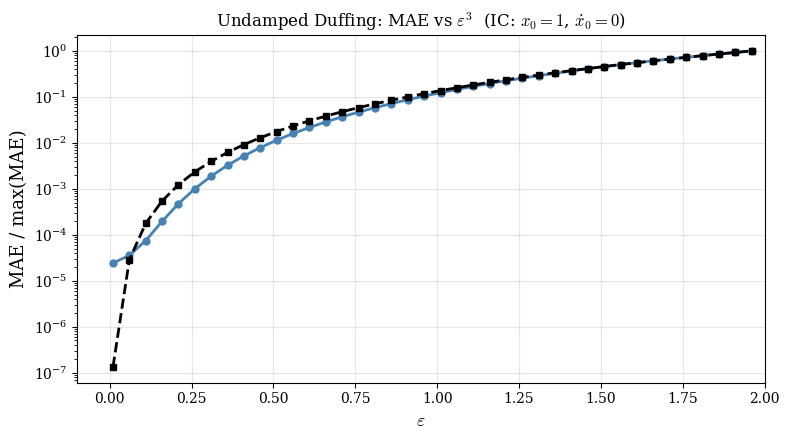

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))

mae_norm = sweep_maes / np.max(sweep_maes)
ref_norm = sweep_eps_ref / np.max(sweep_eps_ref)

ax.plot(sweep_eps, mae_norm, "o-", linewidth=2, markersize=5,
        color="steelblue", label=rf"MAE @ $p={p_max}$")
ax.plot(sweep_eps, ref_norm, "s--", linewidth=2, markersize=4,
        color="black", label=rf"$\varepsilon^{{{p_max}}}$")

ax.set_xlabel(r"$\varepsilon$", fontsize=13)
ax.set_ylabel("MAE / max(MAE)", fontsize=13)
ax.set_title(
    rf"Undamped Duffing: MAE vs $\varepsilon^{{{p_max}}}$  "
    rf"(IC: $x_0=1$, $\dot{{x}}_0=0$)",
    fontsize=12,
)
#ax.legend(frameon=False, fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, sweep_eps.max())
ax.set_yscale("log")
ax.set_xlim(-0.1, 2.0)

plt.tight_layout()
plt.show()